# 10 — Tea Catechin Altitude Regression (New Crop)

Camellia sinensis green tea: total catechin concentration (g/100g dry leaf) vs altitude.

Key methodological notes:
- **Green tea only** — catechins are preserved; black tea and ripe pu-erh are excluded
- **Shade-grown excluded** — shade artificially increases catechins (RSU-22 Uji/Shizuoka)
- **Dry leaf basis** — all values in g/100g dry weight for direct comparability
- Cultivar: Camellia sinensis (var. sinensis or assamica noted in RSU)

Saves `../writing/fig_tea.png`

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import linregress

WRITING = '../writing'

from rsu_loader import load_all_rsus
rsus = load_all_rsus()

# Build RSU-level env DataFrame (altitude, temperature)
env_rows = []
for r in rsus:
    env_rows.append({
        'region_id': r.region_id,
        'rsu_name':  r.name,
        'altitude_m': getattr(r.coordinates, 'altitude_m', None),
        'temp_mean':  r.climate.temperature_mean,
    })
env_df = pd.DataFrame(env_rows).set_index('region_id')

import os
matrix_path = '../data/metabolites/rsu_metabolite_matrix.csv'
if os.path.exists(matrix_path):
    food_df_raw = pd.read_csv(matrix_path, index_col=[0, 1])
    # Merge env columns into food_df
    food_df = food_df_raw.join(env_df, on='region_id')
    print(f'Loaded matrix: {food_df.shape}')
else:
    raise FileNotFoundError('Run notebook 01 first to build the metabolite matrix')


Loaded matrix: (268, 36)


In [2]:
# ── Extract tea catechin data directly from RSU JSON files ───────────────────
import re as _re

INCLUDE_RSUS = {'RSU-20', 'RSU-27', 'RSU-56', 'RSU-58', 'RSU-61',
                'RSU-62', 'RSU-63', 'RSU-64', 'RSU-65'}
EXCLUDE_RSUS = {'RSU-22', 'RSU-26', 'RSU-57', 'RSU-60'}

def parse_mid(s):
    if not s: return None
    m = _re.search(r'(\d+\.?\d*)\s*[-]\s*(\d+\.?\d*)', str(s))
    if m: return (float(m.group(1)) + float(m.group(2))) / 2
    m = _re.search(r'(\d+\.?\d*)', str(s))
    if m: return float(m.group(1))
    return None

tea_rows = []
for rsu in rsus:
    if rsu.region_id not in INCLUDE_RSUS:
        continue
    alt = getattr(rsu.coordinates, 'altitude_m', None)
    tmp = rsu.climate.temperature_mean
    for food in rsu.staple_foods:
        kfb = food.metabolite_profile.key_flavor_bioactives
        pp = getattr(kfb, 'polyphenol_content', None)
        if pp:
            val = parse_mid(pp)
            if val and 5 < val < 30:
                tea_rows.append({
                    'region_id': rsu.region_id,
                    'rsu_name':  rsu.name,
                    'food_name': food.name,
                    'altitude_m': alt,
                    'temp_mean':  tmp,
                    'catechins_g100g': val,
                })
                break

tea_df = pd.DataFrame(tea_rows).set_index('region_id')
print(f'Tea RSUs loaded: {len(tea_df)}')
print()
print(tea_df[['rsu_name','altitude_m','temp_mean','catechins_g100g']].sort_values('altitude_m').to_string())

Tea RSUs loaded: 9

                                                        rsu_name  altitude_m  temp_mean  catechins_g100g
region_id                                                                                               
RSU-62             Hangzhou West Lake Longjing, Zhejiang (~100m)         100       17.0           13.990
RSU-63       Kangra Valley Tea, Himachal Pradesh, India (~1290m)        1290       16.0           16.965
RSU-56                Da Lat Central Highlands, Vietnam (~1500m)        1500       18.0           14.250
RSU-61               Yunnan Raw Pu-erh Highlands, China (~1750m)        1750       19.0           16.250
RSU-27                                          Kenyan Highlands        1800       17.0           17.500
RSU-20                            Darjeeling Himalayan Foothills        2000       13.0           20.000
RSU-64     Timbilil Tea Estate, West Rift Valley, Kenya (~2020m)        2020       16.0           16.200
RSU-65     Kangaita Tea Estate, Eas

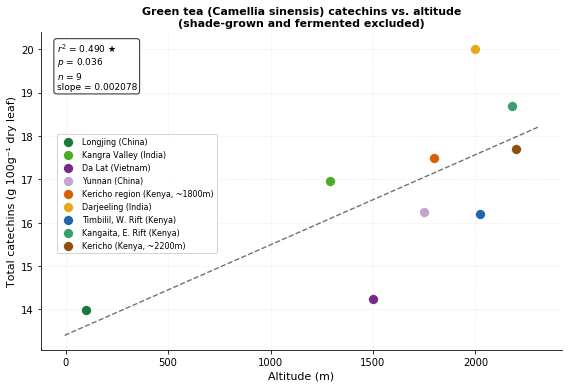

Saved → ../writing/fig_tea.png

Tea catechin regression: r²=0.490, p=0.0357, slope=0.002078 g/100g per m


In [3]:
# ── Fig: Tea catechin vs altitude ─────────────────────────────────────────────
RCPARAMS = {'font.family': 'sans-serif', 'axes.spines.top': False,
            'axes.spines.right': False, 'axes.grid': True,
            'grid.alpha': 0.35, 'grid.linestyle': ':'}

TEA_COLORS = [
    '#1b7837', '#4dac26', '#762a83', '#c2a5cf',
    '#d95f02', '#e6a817', '#2166ac', '#3a9e6f',
    '#8c510a', '#bf812d',  # RSU-64 (Timbilil), RSU-65 (Kangaita)
]

RSU_LABELS = {
    'RSU-20': 'Darjeeling (India)',
    'RSU-27': 'Kericho region (Kenya, ~1800m)',
    'RSU-56': 'Da Lat (Vietnam)',
    'RSU-58': 'Kericho (Kenya, ~2200m)',
    'RSU-61': 'Yunnan (China)',
    'RSU-62': 'Longjing (China)',
    'RSU-63': 'Kangra Valley (India)',
    'RSU-64': 'Timbilil, W. Rift (Kenya)',
    'RSU-65': 'Kangaita, E. Rift (Kenya)',
}

def ols_line(ax, x, y, color='black', lw=1.4, alpha=0.55):
    from scipy.stats import linregress
    x, y = np.asarray(x, float), np.asarray(y, float)
    mask = ~(np.isnan(x) | np.isnan(y))
    if mask.sum() < 2: return None, None, None
    sl, inter, r, p, _ = linregress(x[mask], y[mask])
    pad = (x[mask].max() - x[mask].min()) * 0.05
    xl = np.linspace(x[mask].min() - pad, x[mask].max() + pad, 200)
    ax.plot(xl, sl * xl + inter, '--', color=color, lw=lw, alpha=alpha)
    return r**2, p, sl

def ann(ax, r2, p, n, slope=None, loc='upper left'):
    sig = ' ★★★' if p < 0.001 else (' ★★' if p < 0.01 else (' ★' if p < 0.05 else (' †' if p < 0.10 else '')))
    txt = f'$r^2$ = {r2:.3f}{sig}\n$p$ = {p:.3f}\n$n$ = {n}'
    if slope is not None:
        txt += f'\nslope = {slope:.4g}'
    ha  = 'left'  if 'left'  in loc else 'right'
    va  = 'top'   if ('top' in loc or 'upper' in loc) else 'bottom'
    x0  = 0.03    if 'left'  in loc else 0.97
    y0  = 0.97    if ('top' in loc or 'upper' in loc) else 0.03
    ax.text(x0, y0, txt, transform=ax.transAxes, ha=ha, va=va, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

if 'catechins_g100g' not in tea_df.columns or len(tea_df) < 2:
    print('Insufficient tea catechin data — run after loading tea RSUs')
else:
    xs, ys = [], []
    with plt.rc_context(RCPARAMS):
        fig, ax = plt.subplots(figsize=(8, 5.5))

        for ci, (idx, row) in enumerate(tea_df.sort_values('altitude_m').iterrows()):
            rsu_id = idx[0] if isinstance(idx, tuple) else idx
            x_val = pd.to_numeric(row.get('altitude_m'), errors='coerce')
            y_val = pd.to_numeric(row.get('catechins_g100g'), errors='coerce')
            if np.isnan(x_val) or np.isnan(y_val):
                continue
            label = RSU_LABELS.get(rsu_id, rsu_id)
            color = TEA_COLORS[ci % len(TEA_COLORS)]
            ax.scatter(x_val, y_val, color=color, s=100, zorder=4,
                       edgecolors='white', linewidths=0.7, label=label)
            xs.append(x_val); ys.append(y_val)

        r2, p, slope = ols_line(ax, xs, ys, color='black')
        if r2 is not None:
            ann(ax, r2, p, len(xs), slope=slope, loc='upper left')

        ax.set_xlabel('Altitude (m)', fontsize=11)
        ax.set_ylabel('Total catechins (g 100g⁻¹ dry leaf)', fontsize=11)
        ax.set_title('Green tea (Camellia sinensis) catechins vs. altitude\n'
                     '(shade-grown and fermented excluded)', fontsize=11, fontweight='bold')
        # Legend upper left, below stats annotation box
        ax.legend(fontsize=8, framealpha=0.85, loc='upper left',
                  bbox_to_anchor=(0.03, 0.68), borderaxespad=0)

        plt.tight_layout()
        path = f'{WRITING}/fig_tea.png'
        fig.savefig(path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f'Saved → {path}')
        if r2 is not None:
            print(f'\nTea catechin regression: r²={r2:.3f}, p={p:.4f}, slope={slope:.4g} g/100g per m')
        else:
            print('Could not fit regression — check that altitude_m is present in tea_df')

In [4]:
# ── LOOCV for tea ─────────────────────────────────────────────────────────────
if 'catechins_g100g' in tea_df.columns and len(tea_df) >= 4:
    xs = pd.to_numeric(tea_df['altitude_m'], errors='coerce').values
    ys = pd.to_numeric(tea_df['catechins_g100g'], errors='coerce').values
    rsu_ids = tea_df.index.get_level_values('region_id').values
    mask = ~(np.isnan(xs) | np.isnan(ys))
    xs, ys, rsu_ids = xs[mask], ys[mask], rsu_ids[mask]

    print('Tea LOOCV:')
    print(f'{"Dropped":<12} {"r²":>8} {"p":>8} {"slope":>12}')
    for i in range(len(xs)):
        xi = np.delete(xs, i)
        yi = np.delete(ys, i)
        if len(xi) < 2: continue
        sl, inter, r, p, _ = linregress(xi, yi)
        stars = ' ★★' if p < 0.01 else (' ★' if p < 0.05 else (' †' if p < 0.10 else ''))
        print(f'{rsu_ids[i]:<12} {r**2:>8.3f} {p:>8.3f} {sl:>12.4g}{stars}')
else:
    print('Not enough tea RSUs for LOOCV (need n ≥ 4)')

Tea LOOCV:
Dropped            r²        p        slope
RSU-20          0.553    0.034     0.001787 ★
RSU-27          0.486    0.054     0.002061 †
RSU-56          0.580    0.028     0.001966 ★
RSU-58          0.479    0.057     0.002136 †
RSU-61          0.508    0.047     0.002105 ★
RSU-62          0.304    0.157      0.00296
RSU-63          0.519    0.044     0.002186 ★
RSU-64          0.561    0.032     0.002258 ★
RSU-65          0.442    0.072     0.001933 †
